本文件尝试自定义全连接层。

In [1]:
!python3 --version

Python 3.11.11


In [2]:
!nvidia-smi

Sat Jun  7 05:51:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)

2025-06-07 05:52:00.249529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749275520.500847      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749275520.579095      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0
sys.version_info(major=3, minor=11, micro=11, releaselevel='final', serial=0)
matplotlib 3.7.2
numpy 1.26.4
pandas 2.2.3
sklearn 1.2.2
tensorflow 2.18.0
keras._tf_keras.keras 3.8.0


In [4]:
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

if gpus:
    print(f"GPUs available: {gpus}")
    try:
        # 打印每个GPU的详细信息
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True) # 推荐设置，按需分配显存
            print(f"Details for {gpu.name}:")
            # 可以尝试执行一个小操作来确认
        print("GPU is available and TensorFlow can see it!")

        # 尝试一个简单的GPU运算
        print("\nAttempting a simple computation on GPU...")
        with tf.device('/GPU:0'): # 明确指定在第一个GPU上运行
            a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            b = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            c = tf.matmul(a, b)
        print("Matrix multiplication result from GPU:")
        print(c.numpy())
        print("If no errors occurred, GPU is working!")

    except RuntimeError as e:
        print(f"RuntimeError during GPU setup or test: {e}")
else:
    print("GPU not available to TensorFlow. TensorFlow will run on CPU.")

TensorFlow Version: 2.18.0
Num GPUs Available: 2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Details for /physical_device:GPU:0:
Details for /physical_device:GPU:1:
GPU is available and TensorFlow can see it!

Attempting a simple computation on GPU...
Matrix multiplication result from GPU:
[[ 7. 10.]
 [15. 22.]]
If no errors occurred, GPU is working!


I0000 00:00:1749275534.613517      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749275534.614203      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


要模仿原有的全连接层，就是我们要实现 ``activation(wx+b)`` .

In [5]:
# layer = tf.keras.layers.Dense(100)
layer = tf.keras.layers.Dense(100, input_shape=(None, 5)) # input_shape 往往第一层指定
# layer是输入为5，输出为100的全连接层，所以对于输入为10x5的矩阵来看，会乘以一个5x100的矩阵，所以输出就是10x100.
print(type(layer))
layer(tf.ones([10, 5]))  #这里是对应层的输出

<class 'keras.src.layers.core.dense.Dense'>


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<tf.Tensor: shape=(10, 100), dtype=float32, numpy=
array([[-0.14073512, -0.22899331,  0.27455056,  0.06314094,  0.5227574 ,
         0.08548348, -0.1588734 , -0.1453603 , -0.00444208,  0.54783756,
         0.15640108, -0.24864064, -0.646404  ,  0.3832957 , -0.62895024,
        -0.06854533,  0.08475135, -0.01580356, -0.04159987, -0.27016506,
        -0.09853505,  0.5965845 ,  0.24067321,  0.28755683,  0.46065736,
         0.11566988, -0.04440419,  0.23445426, -0.02636881,  0.06798379,
         0.3898453 ,  0.16999315, -0.38648129, -0.22552119, -0.42254287,
        -0.32854563, -0.13387464,  0.21606982, -0.18952993, -0.41891432,
         0.16978893,  0.20051123,  0.30031508, -0.15878956, -0.2957641 ,
         0.3047489 , -0.30012515, -0.2844298 , -0.3117714 ,  0.07150544,
        -0.25237054, -0.18585923,  0.3246807 , -0.14840877, -0.20317733,
        -0.18182065,  0.08282647, -0.16737574,  0.00161576,  0.14110611,
        -0.30231822, -0.49746847,  0.24568114,  0.23230499, -0.08424152,


In [6]:
# layer.variables 可以打印layer里包含的所有参数
# x * w + b  w 就是指层的参数，kernel就是 w，b就是bias
print(layer.variables)
print('-'*50)
#获得所有可训练的变量
layer.trainable_variables

[<Variable path=dense/kernel, shape=(5, 100), dtype=float32, value=[[-1.88204944e-01 -1.83820873e-01  2.31782600e-01  3.94042283e-02
   1.38525948e-01 -1.74353600e-01 -1.39013827e-02 -8.02703947e-02
   4.72171158e-02  2.05849335e-01  8.45253319e-02 -1.80776194e-01
  -4.78562266e-02 -7.61845708e-02 -1.84931323e-01  1.56605020e-01
   3.38770002e-02  1.62332430e-01 -1.90123782e-01 -2.09496826e-01
   1.29121944e-01  1.24071911e-01  3.77427787e-02 -1.67321563e-02
   1.99911073e-01 -1.63468629e-01  1.53276935e-01  1.29965857e-01
   7.11296946e-02  2.23524198e-01  4.47364300e-02  8.35977048e-02
  -2.07227021e-01  1.98945656e-01 -2.21642703e-02  6.60464913e-02
  -6.60738498e-02  4.15109247e-02 -3.38690281e-02 -1.96364284e-01
   1.06979236e-01 -2.10927635e-01  1.81002393e-01  1.05911687e-01
   1.96506068e-01  1.92786321e-01  8.22054297e-02 -1.06642053e-01
  -2.21373975e-01  1.94706574e-01  2.25186497e-02  1.45701423e-01
   7.54404068e-03  1.38450161e-01 -1.81628704e-01 -7.61662722e-02
  -6.4159

[<Variable path=dense/kernel, shape=(5, 100), dtype=float32, value=[[-1.88204944e-01 -1.83820873e-01  2.31782600e-01  3.94042283e-02
    1.38525948e-01 -1.74353600e-01 -1.39013827e-02 -8.02703947e-02
    4.72171158e-02  2.05849335e-01  8.45253319e-02 -1.80776194e-01
   -4.78562266e-02 -7.61845708e-02 -1.84931323e-01  1.56605020e-01
    3.38770002e-02  1.62332430e-01 -1.90123782e-01 -2.09496826e-01
    1.29121944e-01  1.24071911e-01  3.77427787e-02 -1.67321563e-02
    1.99911073e-01 -1.63468629e-01  1.53276935e-01  1.29965857e-01
    7.11296946e-02  2.23524198e-01  4.47364300e-02  8.35977048e-02
   -2.07227021e-01  1.98945656e-01 -2.21642703e-02  6.60464913e-02
   -6.60738498e-02  4.15109247e-02 -3.38690281e-02 -1.96364284e-01
    1.06979236e-01 -2.10927635e-01  1.81002393e-01  1.05911687e-01
    1.96506068e-01  1.92786321e-01  8.22054297e-02 -1.06642053e-01
   -2.21373975e-01  1.94706574e-01  2.25186497e-02  1.45701423e-01
    7.54404068e-03  1.38450161e-01 -1.81628704e-01 -7.61662722e

In [7]:
help(layer)

Help on Dense in module keras.src.layers.core.dense object:

class Dense(keras.src.layers.layer.Layer)
 |  Dense(units, activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, lora_rank=None, **kwargs)
 |  
 |  Just your regular densely-connected NN layer.
 |  
 |  `Dense` implements the operation:
 |  `output = activation(dot(input, kernel) + bias)`
 |  where `activation` is the element-wise activation function
 |  passed as the `activation` argument, `kernel` is a weights matrix
 |  created by the layer, and `bias` is a bias vector created by the layer
 |  (only applicable if `use_bias` is `True`).
 |  
 |  Note: If the input to the layer has a rank greater than 2, `Dense`
 |  computes the dot product between the `inputs` and the `kernel` along the
 |  last axis of the `inputs` and axis 0 of the `kernel` (using `tf.tensordot`)

In [8]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print(housing.DESCR)
print(housing.data.shape)
print(housing.target.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [9]:
from sklearn.model_selection import train_test_split

x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state = 7)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state = 11)
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)


(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

In [11]:
#使用lamba，一行代码就搞定
# tf.nn.softplus : log(1+e^x)
customized_softplus = keras.layers.Lambda(lambda x : tf.math.log(1+tf.math.exp(x)))
x = tf.constant([-10., -5., 0., 5., 10.])
print(customized_softplus(x))

tf.Tensor([4.5417706e-05 6.7153489e-03 6.9314718e-01 5.0067153e+00 1.0000046e+01], shape=(5,), dtype=float32)


In [12]:
np.log(1+np.exp(-5))

0.006715348489117967

In [13]:
# customized dense layer.
class CustomizedDenseLayer(keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        self.units = units
        self.activation = keras.layers.Activation(activation)  #直接使用tf提供的
        super(CustomizedDenseLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):   # compile 的时候就会调用 build
        """构建所需要的参数，也就是kernel还有bias"""
        # x * w + b. input_shape:[None, a] w:[a,b]output_shape: [None, b]
        print('-'*50)
        print(input_shape)
        self.kernel = self.add_weight(name = 'kernel',
                                      shape = (input_shape[1], self.units), # 这里的1其实非常局限于这个案例
                                      initializer = 'uniform',#使用均匀分布的方法去初始化kernel
                                      trainable = True)
        self.bias = self.add_weight(name = 'bias',
                                    shape = (self.units, ),
                                    initializer = 'zeros',
                                    trainable = True)
        #接着我们要继承父类的build
        super(CustomizedDenseLayer, self).build(input_shape)
    
    def call(self, x):
        """完成正向计算"""
        return self.activation(x @ self.kernel + self.bias)

#完全模仿dense来实现自定义层，因此input_shape传的和dense一致，只需要是特征数，父类Layer自动会转为
#二维的input_shape，然后再传递给build
model = keras.models.Sequential([
    CustomizedDenseLayer(30, activation='relu',
                         input_shape=x_train.shape[1:]),  #这里传入的是特征数
#     CustomizedDenseLayer(1),
    #再加一个激活函数层，这个和下面注释的两行等价的
#     customized_softplus,
    CustomizedDenseLayer(1,activation=customized_softplus),
#     keras.layers.Dense(1, activation="softplus"),  #一层
#     keras.layers.Dense(1), keras.layers.Activation('softplus'), #两层
])
model.summary()
model.compile(loss="mean_squared_error", optimizer="sgd")
callbacks = [keras.callbacks.EarlyStopping(
    patience=5, min_delta=1e-3)]

--------------------------------------------------
(None, 8)
--------------------------------------------------
(None, 30)


/tmp/ipykernel_35/4017886807.py:6: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(CustomizedDenseLayer, self).__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ customized_dense_layer               │ (None, 30)                  │             270 │
│ (CustomizedDenseLayer)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ customized_dense_layer_1             │ (None, 1)                   │              31 │
│ (CustomizedDenseLayer)               │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(x_train_scaled, y_train,
                    validation_data = (x_valid_scaled, y_valid),
                    epochs = 10,
                    callbacks = callbacks)

Epoch 1/10


I0000 00:00:1749275538.307995     100 service.cc:148] XLA service 0x7a506c006f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749275538.308787     100 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749275538.308807     100 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749275538.433190     100 cuda_dnn.cc:529] Loaded cuDNN version 90300


 83/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6860  

I0000 00:00:1749275538.840885     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.8422 - val_loss: 0.6789
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6079 - val_loss: 0.5867
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5307 - val_loss: 0.5245
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4903 - val_loss: 0.4898
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4451 - val_loss: 0.4691
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4526 - val_loss: 0.4682
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4499 - val_loss: 0.4401
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4373 - val_loss: 0.4395
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4124 - val_loss: 0.4405
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4358 - val_loss: 0.4211


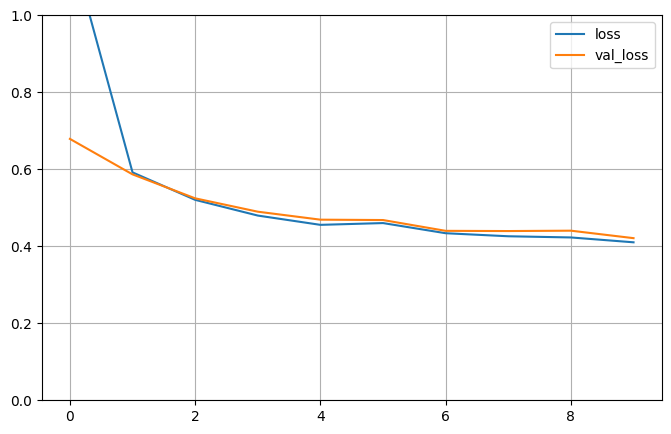

In [15]:
def plot_learning_curves(history):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.show()
plot_learning_curves(history)

In [16]:
model.evaluate(x_test_scaled, y_test, verbose=0)

0.4196316599845886